Sample data:
   Year  Bin_Size  Population_Percentage Category
0  2020        10              12.490802        B
1  2020        20               8.668696        B
2  2020        30              16.937003        F
3  2020        40               8.119890        O
4  2020        50              14.184978        B
5  2021        10              17.022300        O
6  2021        20               5.411690        F
7  2021        30              19.439975        F
8  2021        40               9.246782        B
9  2021        50              17.349630        F

DataFrame shape: (25, 4)

Category distribution:
Category
B    9
O    9
F    7
Name: count, dtype: int64

Creating Bubble Chart with Parallel Categories


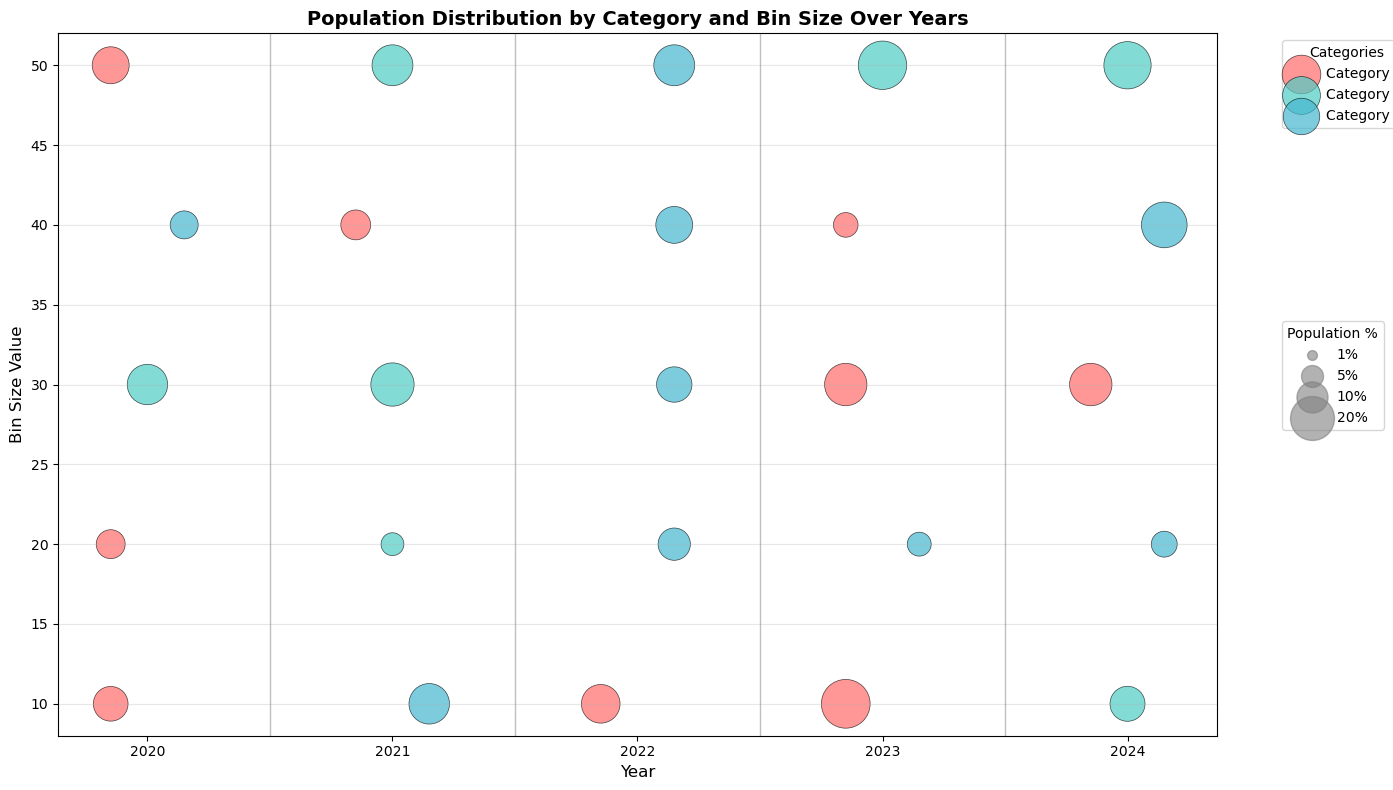


Chart Features:
- Each category (B, F, O) is positioned parallel to others
- Vertical lines separate different years
- Colors: B = Red, F = Teal, O = Blue
- Bubble sizes represent population percentages
- Only horizontal grid lines for cleaner look

Creating Analysis Chart
Category Analysis:
--------------------------------------------------
Category B:
  Count: 9
  Average percentage: 14.26%
  Maximum percentage: 24.66%

Category F:
  Count: 7
  Average percentage: 17.05%
  Maximum percentage: 24.31%

Category O:
  Count: 9
  Average percentage: 12.78%
  Maximum percentage: 21.66%



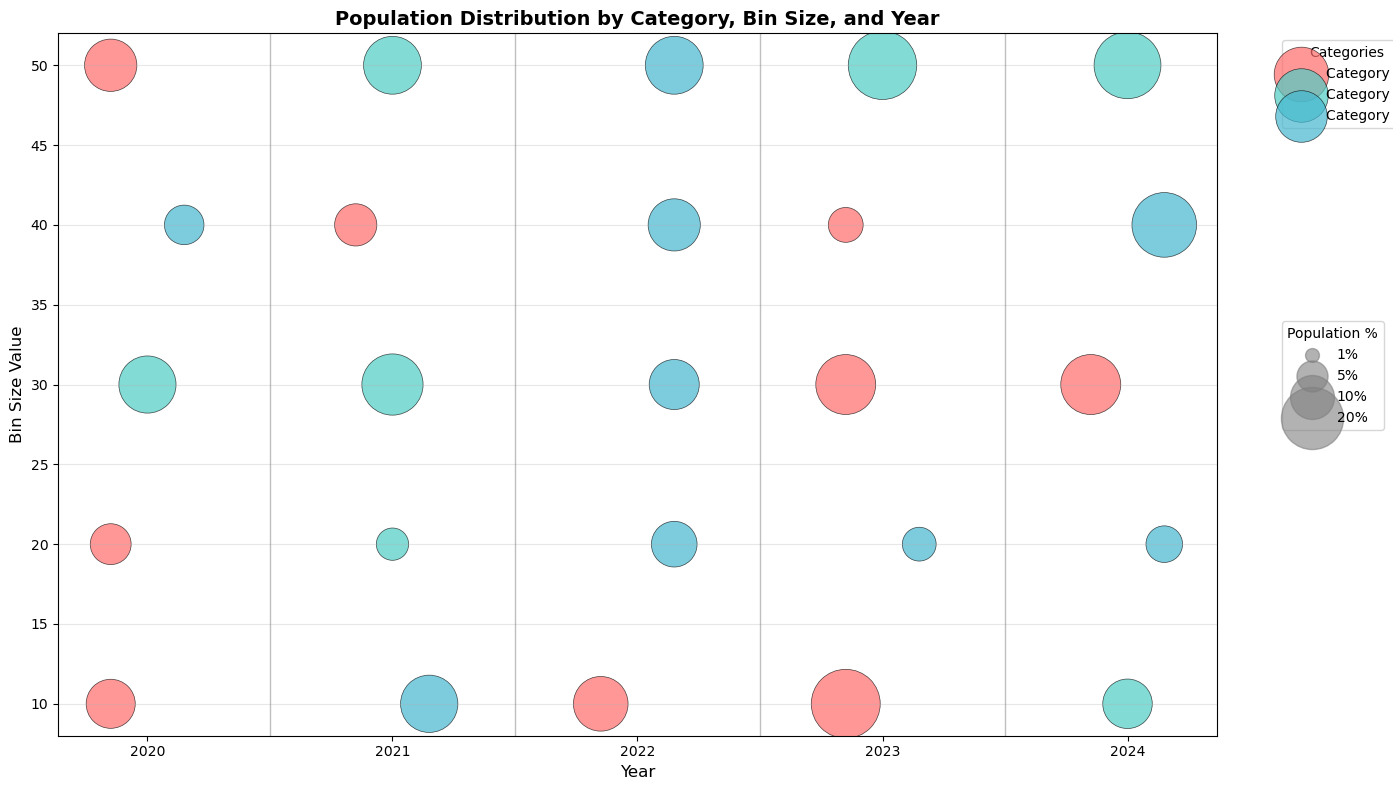


Creating Comparison of Different Offset Values


NameError: name 'compare_parallel_offsets' is not defined

In [5]:
def create_bubble_chart(df, year_col, bin_col, percentage_col, 
                       category_col=None, title="Bubble Chart", size_multiplier=100,
                       parallel_offset=0.15):
    """
    Create a bubble chart from a DataFrame with parallel bubbles for categories
    
    Parameters:
    df: pandas DataFrame containing the data
    year_col: string, name of column containing years (x-axis)
    bin_col: string, name of column containing bin size values (y-axis)
    percentage_col: string, name of column containing population percentages (bubble size)
    category_col: string, optional name of column containing categories (B, F, O) for color coding
    title: string, chart title
    size_multiplier: int, multiplier for bubble sizes (adjust for visibility)
    parallel_offset: float, horizontal offset between parallel bubbles (default: 0.15)
    """
    
    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Define colors for categories B, F, O
    category_colors = {'B': '#FF6B6B', 'F': '#4ECDC4', 'O': '#45B7D1'}
    
    if category_col and category_col in df.columns:
        # Create position offsets for parallel bubbles
        categories = sorted(df[category_col].unique())
        category_offsets = {}
        
        # Calculate offsets: center around 0
        if len(categories) == 1:
            category_offsets[categories[0]] = 0
        elif len(categories) == 2:
            category_offsets[categories[0]] = -parallel_offset/2
            category_offsets[categories[1]] = parallel_offset/2
        else:  # 3 or more categories
            for i, cat in enumerate(categories):
                category_offsets[cat] = (i - 1) * parallel_offset
        
        # Create scatter plot for each category with offset positions
        for category in categories:
            mask = df[category_col] == category
            offset_years = df[mask][year_col] + category_offsets[category]
            
            scatter = ax.scatter(offset_years, 
                               df[mask][bin_col], 
                               s=df[mask][percentage_col] * size_multiplier,
                               alpha=0.7,
                               c=category_colors.get(category, '#666666'),
                               edgecolors='black',
                               linewidth=0.5,
                               label=f'Category {category}')
        
        # Add vertical lines to separate years
        unique_years = sorted(df[year_col].unique())
        for i, year in enumerate(unique_years[:-1]):  # Don't add line after last year
            next_year = unique_years[i + 1]
            separator_x = year + (next_year - year) / 2
            ax.axvline(x=separator_x, color='gray', linestyle='-', alpha=0.5, linewidth=1)
        
        # Add category legend
        category_legend = ax.legend(title="Categories", 
                                  loc='upper left', 
                                  bbox_to_anchor=(1.05, 1))
        
        # Add category legend to the plot
        ax.add_artist(category_legend)
        
    else:
        # Default: color by percentage
        scatter = ax.scatter(df[year_col], 
                           df[bin_col], 
                           s=df[percentage_col] * size_multiplier,
                           alpha=0.6,
                           c=df[percentage_col],
                           cmap='viridis',
                           edgecolors='black',
                           linewidth=0.5)
        
        # Add colorbar to show percentage scale
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Population Percentage (%)', fontsize=10)
    
    # Customize the plot
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Bin Size Value', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    # Add horizontal grid for better readability
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set x-axis to show actual years (not offset positions)
    unique_years = sorted(df[year_col].unique())
    ax.set_xticks(unique_years)
    ax.set_xticklabels(unique_years)
    
    # Create a legend for bubble sizes
    percentages = [1, 5, 10, 20]  # Sample percentages for legend
    size_legend_elements = []
    
    for pct in percentages:
        size_legend_elements.append(plt.scatter([], [], s=pct * size_multiplier, 
                                              alpha=0.6, c='gray', 
                                              label=f'{pct}%'))
    
    # Add size legend
    size_legend = ax.legend(handles=size_legend_elements, 
                          title="Population %", 
                          loc='upper left', 
                          bbox_to_anchor=(1.05, 0.6))
    
    # Adjust layout to prevent legend cutoff
    plt.tight_layout()
    
    # Show the plot
    plt.show()
    
    return fig, ax

# Example usage with sample data
def create_sample_data():
    """Create sample data for demonstration"""
    np.random.seed(42)
    
    years = []
    bin_sizes = []
    percentages = []
    categories = []
    
    # Generate sample data for years 2020-2024
    for year in range(2020, 2025):
        for bin_size in [10, 20, 30, 40, 50]:
            years.append(year)
            bin_sizes.append(bin_size)
            # Generate random percentage with some variation
            base_pct = np.random.uniform(5, 25)
            percentages.append(base_pct)
            # Randomly assign categories B, F, O
            categories.append(np.random.choice(['B', 'F', 'O']))
    
    return pd.DataFrame({
        'Year': years,
        'Bin_Size': bin_sizes,
        'Population_Percentage': percentages,
        'Category': categories
    })

# Example usage
if __name__ == "__main__":
    # Create sample data
    sample_df = create_sample_data()
    
    print("Sample data:")
    print(sample_df.head(10))
    print(f"\nDataFrame shape: {sample_df.shape}")
    print(f"\nCategory distribution:")
    print(sample_df['Category'].value_counts())
    
    # Create the bubble chart with parallel bubbles and year separators
    print("\n" + "="*60)
    print("Creating Bubble Chart with Parallel Categories")
    print("="*60)
    
    fig, ax = create_bubble_chart(sample_df, 
                                 year_col='Year',
                                 bin_col='Bin_Size', 
                                 percentage_col='Population_Percentage',
                                 category_col='Category',
                                 title='Population Distribution by Category and Bin Size Over Years',
                                 size_multiplier=50,
                                 parallel_offset=0.15)  # Adjust this to change spacing
    
    print("\nChart Features:")
    print("- Each category (B, F, O) is positioned parallel to others")
    print("- Vertical lines separate different years")
    print("- Colors: B = Red, F = Teal, O = Blue")
    print("- Bubble sizes represent population percentages")
    print("- Only horizontal grid lines for cleaner look")
    
    # Optional: Create analysis chart
    print("\n" + "="*60)
    print("Creating Analysis Chart")
    print("="*60)
    
    analyze_categories_bubble_chart(sample_df, 'Year', 'Bin_Size', 
                                  'Population_Percentage', 'Category')
    
    # Optional: Compare different offset values
    print("\n" + "="*60)
    print("Creating Comparison of Different Offset Values")
    print("="*60)
    
    compare_parallel_offsets(sample_df, 'Year', 'Bin_Size', 
                           'Population_Percentage', 'Category')
    
    # Optional: Save the chart
    # plt.savefig('bubble_chart_parallel.png', dpi=300, bbox_inches='tight')
    
    print("\nTo adjust bubble spacing, change the 'parallel_offset' parameter:")
    print("- smaller values (0.1) = bubbles closer together")
    print("- larger values (0.3) = bubbles further apart")

# Alternative function for more customization
def create_advanced_bubble_chart(df, year_col, bin_col, percentage_col, 
                                category_col=None, title="Advanced Bubble Chart",
                                custom_colors=None, parallel_offset=0.2):
    """
    Create an advanced bubble chart with parallel bubbles and year separators
    
    Parameters:
    df: pandas DataFrame containing the data
    year_col: string, name of column containing years (x-axis)
    bin_col: string, name of column containing bin size values (y-axis)  
    percentage_col: string, name of column containing population percentages (bubble size)
    category_col: string, optional column name for category-based coloring (B, F, O)
    title: string, chart title
    custom_colors: dict, optional custom color mapping for categories
    parallel_offset: float, horizontal offset between parallel bubbles
    """
    
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Default colors for categories B, F, O
    default_colors = {'B': '#FF6B6B', 'F': '#4ECDC4', 'O': '#45B7D1'}
    colors_to_use = custom_colors if custom_colors else default_colors
    
    if category_col and category_col in df.columns:
        # Create position offsets for parallel bubbles
        categories = sorted(df[category_col].unique())
        category_offsets = {}
        
        # Calculate offsets: center around 0
        if len(categories) == 1:
            category_offsets[categories[0]] = 0
        elif len(categories) == 2:
            category_offsets[categories[0]] = -parallel_offset/2
            category_offsets[categories[1]] = parallel_offset/2
        else:  # 3 or more categories
            for i, cat in enumerate(categories):
                category_offsets[cat] = (i - 1) * parallel_offset
        
        # Create scatter plot for each category with offset positions
        for category in categories:
            mask = df[category_col] == category
            offset_years = df[mask][year_col] + category_offsets[category]
            
            scatter = ax.scatter(offset_years, 
                               df[mask][bin_col], 
                               s=df[mask][percentage_col] * 30,
                               c=colors_to_use.get(category, '#666666'),
                               alpha=0.7,
                               edgecolors='white',
                               linewidth=1,
                               label=f'Category {category}')
        
        # Add vertical lines to separate years with enhanced styling
        unique_years = sorted(df[year_col].unique())
        for i, year in enumerate(unique_years[:-1]):
            next_year = unique_years[i + 1]
            separator_x = year + (next_year - year) / 2
            ax.axvline(x=separator_x, color='#666666', linestyle='--', alpha=0.7, linewidth=1.5)
        
        # Add category legend
        ax.legend(title="Categories", loc='upper left', bbox_to_anchor=(1.05, 1))
        
    else:
        # Use percentage for coloring if no category column
        scatter = ax.scatter(df[year_col], 
                           df[bin_col], 
                           s=df[percentage_col] * 30,
                           c=df[percentage_col],
                           alpha=0.7,
                           cmap='plasma',
                           edgecolors='white',
                           linewidth=1)
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
        cbar.set_label('Population Percentage (%)', fontsize=12)
    
    # Customize appearance
    ax.set_xlabel('Year', fontsize=14, fontweight='bold')
    ax.set_ylabel('Bin Size Value', fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    
    # Set x-axis to show actual years
    unique_years = sorted(df[year_col].unique())
    ax.set_xticks(unique_years)
    ax.set_xticklabels(unique_years)
    
    # Enhance grid - only horizontal lines
    ax.grid(True, alpha=0.4, linestyle='--', axis='y')
    ax.set_facecolor('#f8f9fa')
    
    # Add text annotations for largest bubbles with category info
    max_percentage = df[percentage_col].max()
    for idx, row in df.iterrows():
        if row[percentage_col] > max_percentage * 0.85:  # Annotate top 15% bubbles
            # Calculate offset position if using categories
            x_pos = row[year_col]
            if category_col and category_col in df.columns:
                categories = sorted(df[category_col].unique())
                category_offsets = {}
                if len(categories) == 1:
                    category_offsets[categories[0]] = 0
                elif len(categories) == 2:
                    category_offsets[categories[0]] = -parallel_offset/2
                    category_offsets[categories[1]] = parallel_offset/2
                else:
                    for i, cat in enumerate(categories):
                        category_offsets[cat] = (i - 1) * parallel_offset
                x_pos += category_offsets[row[category_col]]
            
            annotation_text = f'{row[percentage_col]:.1f}%'
            if category_col and category_col in df.columns:
                annotation_text += f' ({row[category_col]})'
            
            ax.annotate(annotation_text, 
                       (x_pos, row[bin_col]),
                       xytext=(5, 5), textcoords='offset points',
                       fontsize=8, alpha=0.8, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

# Function to create bubble chart with custom category analysis
def analyze_categories_bubble_chart(df, year_col, bin_col, percentage_col, category_col,
                                  parallel_offset=0.15):
    """
    Create a bubble chart with parallel bubbles and additional category analysis
    
    Parameters:
    df: pandas DataFrame containing the data
    year_col: string, name of column containing years (x-axis)
    bin_col: string, name of column containing bin size values (y-axis)
    percentage_col: string, name of column containing population percentages (bubble size)
    category_col: string, name of column containing categories (B, F, O)
    parallel_offset: float, horizontal offset between parallel bubbles
    """
    
    # Print category statistics
    print("Category Analysis:")
    print("-" * 50)
    
    for category in sorted(df[category_col].unique()):
        cat_data = df[df[category_col] == category]
        avg_percentage = cat_data[percentage_col].mean()
        max_percentage = cat_data[percentage_col].max()
        count = len(cat_data)
        
        print(f"Category {category}:")
        print(f"  Count: {count}")
        print(f"  Average percentage: {avg_percentage:.2f}%")
        print(f"  Maximum percentage: {max_percentage:.2f}%")
        print()
    
    # Create the chart with parallel bubbles
    fig, ax = create_bubble_chart(df, year_col, bin_col, percentage_col, 
                                 category_col=category_col,
                                 title='Population Distribution by Category, Bin Size, and Year',
                                 parallel_offset=parallel_offset)
    
    print("Chart Features:")
    print("- Bubbles are positioned parallel to each other for easy comparison")
    print("- Vertical lines separate different years")
    print("- Category B = Red, F = Teal, O = Blue")
    print(f"- Parallel offset: {parallel_offset} (adjust this parameter to change spacing)")
    
    return fig, ax

# Function to create a comparison chart showing different offset values
def compare_parallel_offsets(df, year_col, bin_col, percentage_col, category_col):
    """
    Create multiple charts with different parallel offset values for comparison
    """
    
    offsets = [0.1, 0.15, 0.2, 0.25]
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('Comparison of Different Parallel Offset Values', fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    category_colors = {'B': '#FF6B6B', 'F': '#4ECDC4', 'O': '#45B7D1'}
    
    for idx, offset in enumerate(offsets):
        ax = axes[idx]
        
        # Create position offsets for parallel bubbles
        categories = sorted(df[category_col].unique())
        category_offsets = {}
        
        if len(categories) == 1:
            category_offsets[categories[0]] = 0
        elif len(categories) == 2:
            category_offsets[categories[0]] = -offset/2
            category_offsets[categories[1]] = offset/2
        else:
            for i, cat in enumerate(categories):
                category_offsets[cat] = (i - 1) * offset
        
        # Plot each category
        for category in categories:
            mask = df[category_col] == category
            offset_years = df[mask][year_col] + category_offsets[category]
            
            ax.scatter(offset_years, 
                      df[mask][bin_col], 
                      s=df[mask][percentage_col] * 50,
                      alpha=0.7,
                      c=category_colors.get(category, '#666666'),
                      edgecolors='black',
                      linewidth=0.5,
                      label=f'Category {category}')
        
        # Add vertical separators
        unique_years = sorted(df[year_col].unique())
        for i, year in enumerate(unique_years[:-1]):
            next_year = unique_years[i + 1]
            separator_x = year + (next_year - year) / 2
            ax.axvline(x=separator_x, color='gray', linestyle='-', alpha=0.5, linewidth=1)
        
        # Customize subplot
        ax.set_title(f'Parallel Offset = {offset}')
        ax.set_xlabel('Year')
        ax.set_ylabel('Bin Size Value')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xticks(unique_years)
        ax.set_xticklabels(unique_years)
        
        if idx == 0:  # Add legend only to first subplot
            ax.legend(title="Categories", loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return fig, axes